# GPT-2 + LoRA HH-RLHF Prompt Prototype

This notebook is an initial infrastructure prototype for the master's thesis.

It uses Anthropic HH-RLHF conversations as a source of prompts for a small GPT-2 + LoRA workflow.

The goal of this notebook is to verify that:
- GPT-2 can be loaded,
- LoRA adapters can be attached,
- HH-RLHF-style prompts can be extracted,
- responses can be generated,
- a small training loop can run,
- a LoRA adapter can be saved.


## 1. Install Dependencies

In [1]:
# Install required packages
!pip install torch transformers accelerate bitsandbytes
!pip install trl peft datasets
!pip install scipy numpy matplotlib
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
import torchao
print(torchao.__version__)

0.17.0


## 2. Import Libraries

In [3]:
import torch
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer, BitsAndBytesConfig,
    AutoTokenizer, AutoModelForSequenceClassification,
    pipeline
)
from peft import LoraConfig, get_peft_model, TaskType
import gc
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict
import random

## 3. Setup Device and Memory Management

In [4]:
# Clear GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name()}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


## 4. Load GPT-2 with LoRA for Efficient Fine-tuning

In [5]:
# Configure 8-bit quantization for memory efficiency
if device.type == "cuda":
    quantization_config = BitsAndBytesConfig(
        load_in_8bit=True,
        llm_int8_threshold=6.0,
    )
else:
    quantization_config = None

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Load base model
base_model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    quantization_config=quantization_config,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    device_map="auto" if device.type == "cuda" else None,
    low_cpu_mem_usage=True
)

# Configure LoRA for efficient fine-tuning
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=8,  # Low rank
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["c_attn", "c_proj"]  # GPT-2 attention modules
)

# Apply LoRA to the model
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

if not quantization_config:
    model = model.to(device)

print("Model with LoRA loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
Model with LoRA loaded successfully!


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 5. Setup Reward Models (AI Feedback Classifiers)

In [6]:
class RewardModel:
    def __init__(self):
        # Run reward models on CPU for stability
        self.sentiment_classifier = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device=-1
        )

        self.toxicity_classifier = pipeline(
            "text-classification",
            model="unitary/toxic-bert",
            device=-1
        )

    def get_reward(self, text: str) -> float:
        """Calculate composite reward from multiple AI feedback signals"""

        # Safety: avoid extremely long texts for classifiers
        text = text[:1000]

        rewards = []

        try:
            # Sentiment reward
            sentiment_result = self.sentiment_classifier(
                text,
                truncation=True,
                max_length=512
            )[0]

            label = sentiment_result["label"].lower()
            score = sentiment_result["score"]

            if "positive" in label or label == "label_2":
                sentiment_reward = score
            elif "neutral" in label or label == "label_1":
                sentiment_reward = 0.5
            else:
                sentiment_reward = 1.0 - score

            rewards.append(sentiment_reward)

            # Toxicity reward
            toxicity_result = self.toxicity_classifier(
                text,
                truncation=True,
                max_length=512
            )[0]

            toxicity_score = toxicity_result["score"]

            # toxic-bert usually gives a toxicity score
            toxicity_reward = 1.0 - toxicity_score
            rewards.append(toxicity_reward)

            # Length reward
            words = len(text.split())

            if 10 <= words <= 50:
                length_reward = 1.0
            elif words < 10:
                length_reward = words / 10
            else:
                length_reward = max(0.1, 1 - (words - 50) / 100)

            rewards.append(length_reward)

        except Exception as e:
            print(f"Error in reward calculation: {e}")
            return 0.1

        weights = [0.4, 0.4, 0.2]
        final_reward = sum(w * r for w, r in zip(weights, rewards))

        return np.clip(final_reward, 0.0, 1.0)


reward_model = RewardModel()
print("Reward models loaded successfully!")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Reward models loaded successfully!


## 6. Simple RL Training Loop

In [7]:
class SimpleRLTrainer:
    def __init__(self, model, tokenizer, reward_model, learning_rate=1e-5):
        self.model = model
        self.tokenizer = tokenizer
        self.reward_model = reward_model
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
        self.reward_history = []

    def generate_and_score(self, prompt: str, num_samples: int = 4) -> List[Dict]:
        """Generate multiple completions and score them"""

        encoded = self.tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(device)

        input_ids = encoded["input_ids"]
        attention_mask = encoded["attention_mask"]
        prompt_len = input_ids.shape[1]

        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=50,
                num_return_sequences=num_samples,
                temperature=0.8,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id,
                no_repeat_ngram_size=2
            )

        samples = []

        for output in outputs:
            text = self.tokenizer.decode(output, skip_special_tokens=True)

            completion_tokens = output[prompt_len:]
            completion = self.tokenizer.decode(
                completion_tokens,
                skip_special_tokens=True
            ).strip()

            reward_text = completion if completion else text
            reward = self.reward_model.get_reward(reward_text)

            samples.append({
                "text": text,
                "completion": completion,
                "tokens": output.detach().cpu(),
                "prompt_len": prompt_len,
                "reward": reward
            })

        return samples

    def compute_policy_loss(self, samples: List[Dict], baseline_reward: float = None) -> torch.Tensor:
        """Compute REINFORCE policy loss only on generated completion tokens"""

        if baseline_reward is None:
            baseline_reward = np.mean([s["reward"] for s in samples])

        total_loss = 0

        for sample in samples:
            tokens = sample["tokens"].unsqueeze(0).to(device)
            reward = sample["reward"]
            prompt_len = sample["prompt_len"]

            with torch.enable_grad():
                outputs = self.model(tokens)

                logits = outputs.logits[:, :-1, :]
                targets = tokens[:, 1:]

                log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
                token_log_probs = log_probs.gather(
                    2,
                    targets.unsqueeze(-1)
                ).squeeze(-1)

                # In shifted LM targets, completion starts at prompt_len - 1
                completion_start = max(prompt_len - 1, 0)
                completion_log_probs = token_log_probs[:, completion_start:]

                if completion_log_probs.numel() == 0:
                    completion_log_probs = token_log_probs

                advantage = reward - baseline_reward

                loss = -torch.mean(completion_log_probs) * advantage
                total_loss += loss

        return total_loss / len(samples)

    def train_step(self, prompts: List[str]) -> float:
        """Single training step"""

        self.model.train()
        total_reward = 0
        total_loss = 0

        for prompt in prompts:
            samples = self.generate_and_score(prompt, num_samples=2)

            loss = self.compute_policy_loss(samples)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            avg_reward = np.mean([s["reward"] for s in samples])
            total_reward += avg_reward
            total_loss += loss.item()

            if device.type == "cuda":
                torch.cuda.empty_cache()

        avg_reward = total_reward / len(prompts)
        avg_loss = total_loss / len(prompts)

        self.reward_history.append(avg_reward)

        return avg_reward, avg_loss


trainer = SimpleRLTrainer(model, tokenizer, reward_model, learning_rate=5e-6)
print("RL Trainer initialized!")

RL Trainer initialized!


## 7. Test Initial Model Performance

In [8]:
# Test prompts
test_prompts = [
    "Human: What is the key to happiness?\n\nAssistant:",
    "Human: How will technology change the future?\n\nAssistant:",
    "Human: What makes someone a good friend?\n\nAssistant:"
]

print("=== BEFORE TRAINING ===")
model.eval()
initial_rewards = []

for prompt in test_prompts:
    samples = trainer.generate_and_score(prompt, num_samples=2)
    best_sample = max(samples, key=lambda x: x['reward'])
    initial_rewards.append(best_sample['reward'])

    print(f"\nPrompt: {prompt}")
    print(f"Best completion: {best_sample['completion']}")
    print(f"Reward: {best_sample['reward']:.3f}")

print(f"\nAverage initial reward: {np.mean(initial_rewards):.3f}")

=== BEFORE TRAINING ===

Prompt: Human: What is the key to happiness?

Assistant:
Best completion: Well, the idea is to find things that are pleasing to you, and when we find them it is easy to get out of doing that. If we keep doing the things we want to do, we'll just be happy.
, in the
Reward: 0.928

Prompt: Human: How will technology change the future?

Assistant:
Best completion: I want to see things going in the right direction – and not necessarily in an entirely bad direction.
 or
I want people to be able to think, but not thinking.


Or, I don't think technology has to change anything.
Reward: 0.800

Prompt: Human: What makes someone a good friend?

Assistant:
Best completion: The person's good attitude is a function of social interaction with others and what motivates them. When people have good social interactions with each other, their emotional reactivity and intelligence can become more effective than their self-esteem.
-John
Reward: 0.935

Average initial reward: 0.888


## 8. Run RLAIF Training Loop

In [9]:
from datasets import load_dataset

hh = load_dataset(
    "Anthropic/hh-rlhf",
    split="train[:20]"
)

print(hh)
print(hh[0].keys())
print(hh[0]["chosen"][:500])

def extract_prompt_from_hh(text, max_chars=800):
    """
    Extract a short HH-RLHF-style prompt.
    Keeps only the last Human -> Assistant turn.
    """

    parts = text.split("\n\nHuman:")

    if len(parts) > 1:
        last_turn = "Human:" + parts[-1]
    else:
        last_turn = text

    marker = "\n\nAssistant:"
    idx = last_turn.rfind(marker)

    if idx != -1:
        prompt = last_turn[:idx + len(marker)]
    else:
        prompt = last_turn

    prompt = prompt.strip()

    if len(prompt) > max_chars:
        prompt = prompt[-max_chars:]

    return prompt


training_prompts = [
    extract_prompt_from_hh(example["chosen"])
    for example in hh
]

print("Number of prompts:", len(training_prompts))
print("\nExample prompt:\n")
print(training_prompts[0])

# Training loop
num_epochs = 3
batch_size = 1

print("=== STARTING RLAIF TRAINING ON HH-RLHF PROMPTS ===")
print(f"Training for {num_epochs} epochs with batch size {batch_size}")

for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")

    # Shuffle and batch prompts
    shuffled_prompts = random.sample(training_prompts, len(training_prompts))

    epoch_rewards = []
    epoch_losses = []

    for i in range(0, len(shuffled_prompts), batch_size):
        batch_prompts = shuffled_prompts[i:i+batch_size]
        avg_reward, avg_loss = trainer.train_step(batch_prompts)

        epoch_rewards.append(avg_reward)
        epoch_losses.append(avg_loss)

        print(f"  Batch {i//batch_size + 1}: Reward={avg_reward:.3f}, Loss={avg_loss:.3f}")

    # Epoch summary
    #epoch_avg_reward = np.mean(epoch_rewards)
    #epoch_avg_loss = np.mean(epoch_losses)
    #print(f"Epoch {epoch + 1} Summary: Avg Reward={epoch_avg_reward:.3f}, Avg Loss={epoch_avg_loss:.3f}")

    print(
        f"Epoch {epoch + 1} Summary: "
        f"Avg Reward={np.mean(epoch_rewards):.3f}, "
        f"Avg Loss={np.mean(epoch_losses):.3f}"
    )


print("\n=== TRAINING COMPLETE ===")

README.md:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

helpful-rejection-sampled/train.jsonl.gz:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

...

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 20
})
dict_keys(['chosen', 'rejected'])


Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, jizz, jizz-licking, prostitute, slut, cheater, fornicator, floozy, wetback, Mexican, Hispanic, sodomite, midget, mama’s boy, faggot, pervert, queer,
Number of prompts: 20

Example prompt:

Human: What's your favorite one?

Assistant:
=== STARTING RLAIF TRAINING ON HH-RLHF PROMPTS ===
Training for 3 epochs with batch size 1

--- Epoch 1/3 ---
  Batch 1: Reward=0.830, Loss=-0.014
  Batch 2: Reward=0.578, Loss=0.090
  Batch 3: Reward=0.805, Loss=-0.011
  Batch 4: Reward=0.569, Loss=0.098
  Batch 5: Reward=0.799, Loss=-0.768
  Batch 6: Reward=0

## 9. Test Improved Model Performance

In [10]:
print("=== AFTER TRAINING ===")
model.eval()
final_rewards = []

for prompt in test_prompts:
    samples = trainer.generate_and_score(prompt, num_samples=2)
    best_sample = max(samples, key=lambda x: x['reward'])
    final_rewards.append(best_sample['reward'])

    print(f"\nPrompt: {prompt}")
    print(f"Best completion: {best_sample['completion']}")
    print(f"Reward: {best_sample['reward']:.3f}")

print(f"\nAverage final reward: {np.mean(final_rewards):.3f}")
print(f"Improvement: {np.mean(final_rewards) - np.mean(initial_rewards):.3f}")

=== AFTER TRAINING ===

Prompt: Human: What is the key to happiness?

Assistant:
Best completion: If we're honest, what is happiness like? We are not always happy. We're constantly trying to get better at whatever we are trying.
, I'm a pretty great dancer! I can perform very well at a party, but I have
Reward: 0.884

Prompt: Human: How will technology change the future?

Assistant:
Best completion: I'm excited to see what the next four or five-generation AI will look like. It's going to be very interesting. The technology is pretty interesting, as you see in the field, but there's a lot of work to do. People
Reward: 0.993

Prompt: Human: What makes someone a good friend?

Assistant:
Best completion: Oh, no, that's not a friend.
[Parks and Recreation]
: Okay. I think, when a new character comes along, the tone really shifts. If you look at a lot of people as a group, you'll
Reward: 0.800

Average final reward: 0.892
Improvement: 0.004


## 10. Visualize Training Progress

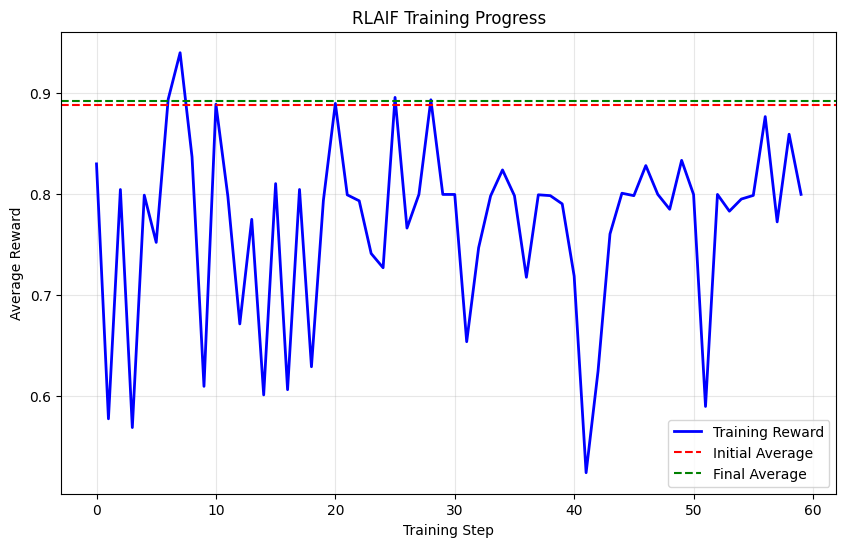

Training Statistics:
  Initial reward: 0.888 ± 0.062
  Final reward: 0.892 ± 0.079
  Total improvement: 0.004
  Training steps: 60


In [11]:
# Plot reward progression
plt.figure(figsize=(10, 6))
plt.plot(trainer.reward_history, 'b-', linewidth=2, label='Training Reward')
plt.axhline(y=np.mean(initial_rewards), color='r', linestyle='--', label='Initial Average')
plt.axhline(y=np.mean(final_rewards), color='g', linestyle='--', label='Final Average')
plt.xlabel('Training Step')
plt.ylabel('Average Reward')
plt.title('RLAIF Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics
print(f"Training Statistics:")
print(f"  Initial reward: {np.mean(initial_rewards):.3f} ± {np.std(initial_rewards):.3f}")
print(f"  Final reward: {np.mean(final_rewards):.3f} ± {np.std(final_rewards):.3f}")
print(f"  Total improvement: {np.mean(final_rewards) - np.mean(initial_rewards):.3f}")
print(f"  Training steps: {len(trainer.reward_history)}")

## 11. Interactive Testing

In [12]:
def interactive_test(prompt: str, num_samples: int = 3):
    """Test the trained model interactively"""
    model.eval()
    samples = trainer.generate_and_score(prompt, num_samples=num_samples)

    # Sort by reward
    samples.sort(key=lambda x: x['reward'], reverse=True)

    print(f"\nPrompt: '{prompt}'")
    print("="*50)

    for i, sample in enumerate(samples):
        print(f"\nRank {i+1} (Reward: {sample['reward']:.3f})")
        print(f"Completion: {sample['completion']}")

# Test with your own prompts
test_prompt = "Human: How can I become more confident?\n\nAssistant:"
interactive_test(test_prompt)


Prompt: 'Human: How can I become more confident?

Assistant:'

Rank 1 (Reward: 0.841)
Completion: In other words, you can become stronger. You can learn to act smarter. And you'll be able to get better at it. If you're not confident in yourself, then you don't want to be. So when you come from a certain

Rank 2 (Reward: 0.800)
Completion: I haven't learned anything about your life yet, isn't it? I promise that if you're going to read this, read it.
 (Laughter)
. Well, you've gotten to know yourself. I have my own special

Rank 3 (Reward: 0.798)
Completion: Well, the fact that you're a young woman and you don't know anyone, and now you've reached this new realm we've got to make sure that we're doing things right, you know, because right now, I'm still learning the


## 12. Your Turn - Experiment!

In [13]:
# Experiment area - try different prompts and settings

# 1. Test with your own prompts
interactive_test("Human: Where can I buy flowers?\n\nAssistant:", num_samples=3)

# 2. Try different reward model weights
# Modify the weights in RewardModel.get_reward() method

# 3. Experiment with different generation parameters
# Modify temperature, max_length, etc. in generate_and_score()

# 4. Add more training epochs
# Re-run the training loop with more epochs

# Your code here:



Prompt: 'Human: Where can I buy flowers?

Assistant:'

Rank 1 (Reward: 0.927)
Completion: You can buy a flower, but if you want it, it's much better than selling it for $50.
 The woman who is buying the flowers will say, when she's done buying flowers, "This is a beautiful flower. It's

Rank 2 (Reward: 0.800)
Completion: I can buy them from flower stores, but I'm unable to buy from the supermarket in front of me
. [To the woman who is waiting for him]: Can you buy flower products from Amazon? Can I sell things on Amazon here? [

Rank 3 (Reward: 0.800)
Completion: We can sell flowers for a profit.
...
 and,
(to Susan)
I have not been to any flower farms yet, you can go on vacation now and I'll be there... but I like flowers. I have a very


## 13. Save Your Trained Model

In [14]:
# Save the LoRA adapter (much smaller than full model)
model.save_pretrained("./gpt2-rlaif-adapter")
tokenizer.save_pretrained("./gpt2-rlaif-adapter")

print("Model saved successfully!")
print("You can load it later with:")
print("from peft import PeftModel")
print("model = PeftModel.from_pretrained(base_model, './gpt2-rlaif-adapter')")

Model saved successfully!
You can load it later with:
from peft import PeftModel
model = PeftModel.from_pretrained(base_model, './gpt2-rlaif-adapter')


## 14. Clean Up Memory

In [15]:
# Clean up GPU memory when done
if device.type == "cuda":
    torch.cuda.empty_cache()
    gc.collect()
    print("GPU memory cleared")
else:
    print("CPU cleanup complete")

print("\n=== RLAIF Training Session Complete! ===")

CPU cleanup complete

=== RLAIF Training Session Complete! ===
